# Latent SDE + SciML Regularization + Score Bridge

Notebook para: 
1. Simular trajetorias de uma SDE (OU) usando os scripts do projeto.
2. Treinar uma **Latent SDE** em JAX/Equinox.
3. Incluir regularizacao fisica (consistencia de derivada e suavidade de difusao).
4. Incluir **Score Bridge** via alvo de gradiente de log em $x_t$.

In [32]:
from pathlib import Path
import sys

ROOT = Path.cwd()
FLUIDS_DIR = ROOT / "fluids"
if str(FLUIDS_DIR) not in sys.path:
    sys.path.append(str(FLUIDS_DIR))

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt

from generator import generate_ou_process_jax

jax.config.update("jax_enable_x64", False)
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


In [33]:
# Dados sinteticos com o gerador existente (OU process).
key = jax.random.PRNGKey(123)
n_paths = 512
n_steps = 180
dt = 0.01

X = generate_ou_process_jax(
    key,
    n_paths=n_paths,
    n_steps=n_steps,
    dt=dt,
    theta=0.8,
    mu=0.0,
    sigma=0.25,
    x0=0.0,
)

# Shape final: (B, T, 1)
X = X[..., None]
t_grid = jnp.arange(n_steps) * dt

print("X shape:", X.shape)
print("t shape:", t_grid.shape)

X shape: (512, 180, 1)
t shape: (180,)


## Modelo Latent SDE

- Encoder: $x_t 	o z_t$
- Dinamica no latente: $dz_t = f_\theta(z_t, t)dt + g_\theta(z_t,t)dW_t$
- Decoder: $z_t 	o x_t$
- Score net: aproxima $\nabla_x \log p_t(x_t)$

In [34]:
def _stack_state_time(state, t):
    state = jnp.asarray(state).reshape(-1, 1)
    t = jnp.asarray(t).reshape(-1, 1)
    return jnp.concatenate([state, t], axis=-1)


class LatentSDE(eqx.Module):
    encoder: eqx.nn.MLP
    decoder: eqx.nn.MLP
    drift: eqx.nn.MLP
    diffusion: eqx.nn.MLP
    score: eqx.nn.MLP

    def __init__(self, key, width=64, depth=2):
        k1, k2, k3, k4, k5 = jax.random.split(key, 5)

        self.encoder = eqx.nn.MLP(1, 1, width_size=width, depth=depth, key=k1)
        self.decoder = eqx.nn.MLP(1, 1, width_size=width, depth=depth, key=k2)

        self.drift = eqx.nn.MLP(2, 1, width_size=width, depth=depth, key=k3)
        self.diffusion = eqx.nn.MLP(2, 1, width_size=width, depth=depth, key=k4)
        self.score = eqx.nn.MLP(2, 1, width_size=width, depth=depth, key=k5)

    def encode(self, x):
        x = jnp.asarray(x).reshape(-1, 1)
        return jax.vmap(self.encoder)(x)

    def decode(self, z):
        z = jnp.asarray(z).reshape(-1, 1)
        return jax.vmap(self.decoder)(z)

    def drift_fn(self, z, t):
        zt = _stack_state_time(z, t)
        return jax.vmap(self.drift)(zt)

    def diffusion_fn(self, z, t):
        zt = _stack_state_time(z, t)
        raw = jax.vmap(self.diffusion)(zt)
        return jax.nn.softplus(raw) + 1e-3

    def score_fn(self, x, t):
        xt = _stack_state_time(x, t)
        return jax.vmap(self.score)(xt)

In [35]:
def mse(a, b):
    return jnp.mean((a - b) ** 2)


def huber(a, b, delta=5.0):
    r = a - b
    abs_r = jnp.abs(r)
    quad = jnp.minimum(abs_r, delta)
    lin = abs_r - quad
    return jnp.mean(0.5 * quad**2 + delta * lin)


def make_time_features(batch_size, t_grid):
    t = t_grid[:-1][None, :, None]
    return jnp.broadcast_to(t, (batch_size, t_grid.shape[0] - 1, 1))


def loss_terms(model, x_batch, t_grid, dt, key, score_sigma=0.08):
    # Transicoes observadas
    x_t = x_batch[:, :-1, :]
    x_next = x_batch[:, 1:, :]
    dx = x_next - x_t

    bsz, tlen, _ = x_t.shape
    t_bt = make_time_features(bsz, t_grid)

    x_t_f = x_t.reshape(-1, 1)
    x_next_f = x_next.reshape(-1, 1)
    dx_f = dx.reshape(-1, 1)
    t_f = t_bt.reshape(-1, 1)

    # Latent dynamics
    z_t = model.encode(x_t_f)
    z_next = model.encode(x_next_f)
    dz = z_next - z_t

    drift = model.drift_fn(z_t, t_f)
    diffusion = model.diffusion_fn(z_t, t_f)

    # NLL Euler-Maruyama no latente
    mean = drift * dt
    var = jnp.clip((diffusion ** 2) * dt, 1e-6, 10.0)
    nll = 0.5 * jnp.mean(((dz - mean) ** 2) / var + jnp.log(var))

    # Reconstrucao no espaco observado
    rec_t = model.decode(z_t)
    rec_next = model.decode(z_next)
    recon = 0.5 * (mse(rec_t, x_t_f) + mse(rec_next, x_next_f))

    # Evita gauge freedom encoder/decoder que causa colapso no latente.
    latent_anchor = 0.5 * (mse(z_t, x_t_f) + mse(z_next, x_next_f))

    # Regulariza derivada do decoder para nao achatar variacao em x.
    eps_jac = 1e-2
    dec = model.decode(z_t)
    dec_plus = model.decode(z_t + eps_jac)
    dec_slope = (dec_plus - dec) / eps_jac
    decoder_slope = mse(dec_slope, jnp.ones_like(dec_slope))

    # SciML vibes: consistencia fisica
    dz_dt_emp = dz / dt
    phys_derivative = mse(dz_dt_emp, drift)

    diffusion_bt = diffusion.reshape(bsz, tlen, 1)
    diff_smooth = jnp.mean((diffusion_bt[:, 1:, :] - diffusion_bt[:, :-1, :]) ** 2)
    physics = phys_derivative + 0.1 * diff_smooth

    # Calibracao da intensidade de ruido usando estatistica empirica de incrementos.
    sigma_emp = jnp.std(dx_f) / jnp.sqrt(dt)
    sigma_emp = jnp.clip(sigma_emp, 1e-2, 2.0)
    diffusion_calib = mse(jnp.log(diffusion + 1e-8), jnp.log(jnp.full_like(diffusion, sigma_emp)))

    # Score matching (denoising) para aproximar grad log p_t(x_t)
    key_noise, _ = jax.random.split(key)
    eps = jax.random.normal(key_noise, shape=x_t_f.shape)
    x_noisy = x_t_f + score_sigma * eps

    score_noisy_pred = model.score_fn(x_noisy, t_f)
    score_target = -(x_noisy - x_t_f) / (score_sigma ** 2)
    score_dsm = mse(score_noisy_pred, score_target)

    # Score Bridge estabilizado: escala minima + clipping + Huber.
    x_pred_step = model.decode(z_t + drift * dt)
    x_drift = x_pred_step - model.decode(z_t)

    x_scale = jnp.clip((diffusion ** 2) * dt, 1e-3, 10.0)
    bridge_target = jax.lax.stop_gradient((dx_f - x_drift) / x_scale)
    bridge_target = jnp.clip(bridge_target, -50.0, 50.0)

    score_xt = model.score_fn(x_t_f, t_f)
    score_bridge = huber(score_xt, bridge_target, delta=5.0)

    return {
        "nll": nll,
        "recon": recon,
        "latent_anchor": latent_anchor,
        "decoder_slope": decoder_slope,
        "physics": physics,
        "diffusion_calib": diffusion_calib,
        "score_dsm": score_dsm,
        "score_bridge": score_bridge,
    }


def total_loss(model, x_batch, t_grid, dt, key, w):
    terms = loss_terms(model, x_batch, t_grid, dt, key)
    total = (
        w["nll"] * terms["nll"]
        + w["recon"] * terms["recon"]
        + w["latent_anchor"] * terms["latent_anchor"]
        + w["decoder_slope"] * terms["decoder_slope"]
        + w["physics"] * terms["physics"]
        + w["diffusion_calib"] * terms["diffusion_calib"]
        + w["score_dsm"] * terms["score_dsm"]
        + w["score_bridge"] * terms["score_bridge"]
    )
    return total, terms


@eqx.filter_jit
def train_step(model, opt_state, x_batch, t_grid, dt, key, optimizer, w):
    (loss, terms), grads = eqx.filter_value_and_grad(total_loss, has_aux=True)(
        model, x_batch, t_grid, dt, key, w
    )
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss, terms

In [36]:
# Treino
key = jax.random.PRNGKey(2026)
model = LatentSDE(key, width=64, depth=2)
optimizer = optax.adam(2e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

weights = {
    "nll": 1.0,
    "recon": 1.0,
    "latent_anchor": 0.5,
    "decoder_slope": 2.0,
    "physics": 0.1,
    "diffusion_calib": 20.0,
    "score_dsm": 0.01,
    "score_bridge": 0.01,
}

num_steps = 1000
batch_size = 128

history = {
    k: []
    for k in [
        "total",
        "nll",
        "recon",
        "latent_anchor",
        "decoder_slope",
        "physics",
        "diffusion_calib",
        "score_dsm",
        "score_bridge",
        "diffusion_mean",
    ]
}

for step in range(1, num_steps + 1):
    key, key_idx, key_train = jax.random.split(key, 3)
    idx = jax.random.choice(key_idx, X.shape[0], shape=(batch_size,), replace=False)
    xb = X[idx]

    model, opt_state, loss, terms = train_step(
        model, opt_state, xb, t_grid, dt, key_train, optimizer, weights
    )

    x_t_diag = xb[:, :-1, :].reshape(-1, 1)
    t_diag = jnp.broadcast_to(t_grid[:-1][None, :, None], (xb.shape[0], t_grid.shape[0] - 1, 1)).reshape(-1, 1)
    z_diag = model.encode(x_t_diag)
    diff_diag = model.diffusion_fn(z_diag, t_diag)

    history["total"].append(float(loss))
    history["nll"].append(float(terms["nll"]))
    history["recon"].append(float(terms["recon"]))
    history["latent_anchor"].append(float(terms["latent_anchor"]))
    history["decoder_slope"].append(float(terms["decoder_slope"]))
    history["physics"].append(float(terms["physics"]))
    history["diffusion_calib"].append(float(terms["diffusion_calib"]))
    history["score_dsm"].append(float(terms["score_dsm"]))
    history["score_bridge"].append(float(terms["score_bridge"]))
    history["diffusion_mean"].append(float(jnp.mean(diff_diag)))

    if step % 100 == 0:
        print(
            f"step {step:04d} | total={loss:.4f} | nll={terms['nll']:.4f} | recon={terms['recon']:.4f} | "
            f"dec_slope={terms['decoder_slope']:.4f} | diff_cal={terms['diffusion_calib']:.4f} | "
            f"bridge={terms['score_bridge']:.4f} | diff_mean={jnp.mean(diff_diag):.4f}"
        )

step 0100 | total=-1.5144 | nll=-3.7105 | recon=0.0262 | dec_slope=0.0001 | diff_cal=0.0008 | bridge=87.0065 | diff_mean=0.2444
step 0200 | total=-1.5428 | nll=-3.7096 | recon=0.0263 | dec_slope=0.0000 | diff_cal=0.0006 | bridge=86.7844 | diff_mean=0.2446
step 0300 | total=-1.5997 | nll=-3.7142 | recon=0.0219 | dec_slope=0.0000 | diff_cal=0.0007 | bridge=86.2400 | diff_mean=0.2439
step 0400 | total=-1.5677 | nll=-3.7121 | recon=0.0281 | dec_slope=0.0000 | diff_cal=0.0005 | bridge=86.7974 | diff_mean=0.2443
step 0500 | total=-1.6183 | nll=-3.7180 | recon=0.0213 | dec_slope=0.0000 | diff_cal=0.0008 | bridge=85.9111 | diff_mean=0.2438
step 0600 | total=-1.5814 | nll=-3.7044 | recon=0.0261 | dec_slope=0.0000 | diff_cal=0.0002 | bridge=86.3447 | diff_mean=0.2449
step 0700 | total=-1.5366 | nll=-3.7068 | recon=0.0305 | dec_slope=0.0000 | diff_cal=0.0007 | bridge=87.2529 | diff_mean=0.2460
step 0800 | total=-1.5754 | nll=-3.7132 | recon=0.0276 | dec_slope=0.0000 | diff_cal=0.0009 | bridge=86.

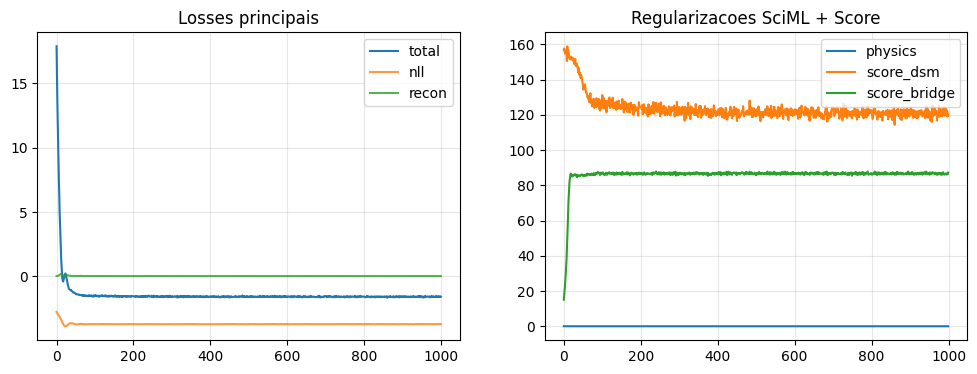

In [37]:
# Diagnosticos de treino
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["total"], label="total")
ax[0].plot(history["nll"], label="nll", alpha=0.8)
ax[0].plot(history["recon"], label="recon", alpha=0.8)
ax[0].set_title("Losses principais")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(history["physics"], label="physics")
ax[1].plot(history["score_dsm"], label="score_dsm")
ax[1].plot(history["score_bridge"], label="score_bridge")
ax[1].set_title("Regularizacoes SciML + Score")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.show()

In [38]:
def simulate_latent_sde(model, key, x0_batch, t_grid, dt):
    z0 = model.encode(x0_batch.reshape(-1, 1))

    def step(z, inp):
        key_step, t_scalar = inp
        t = jnp.full((z.shape[0], 1), t_scalar)

        drift = model.drift_fn(z, t)
        diffusion = model.diffusion_fn(z, t)
        dW = jax.random.normal(key_step, z.shape) * jnp.sqrt(dt)

        z_next = z + drift * dt + diffusion * dW
        x_next = model.decode(z_next)
        return z_next, x_next

    keys = jax.random.split(key, t_grid.shape[0])
    _, x_traj = jax.lax.scan(step, z0, (keys, t_grid))
    # (T, B, 1) -> (B, T, 1)
    return jnp.swapaxes(x_traj, 0, 1)


key_sim = jax.random.PRNGKey(999)
n_sim = 40
x0 = jnp.zeros((n_sim, 1))
X_sim = simulate_latent_sde(model, key_sim, x0, t_grid, dt)

print("Sim shape:", X_sim.shape)

Sim shape: (40, 180, 1)


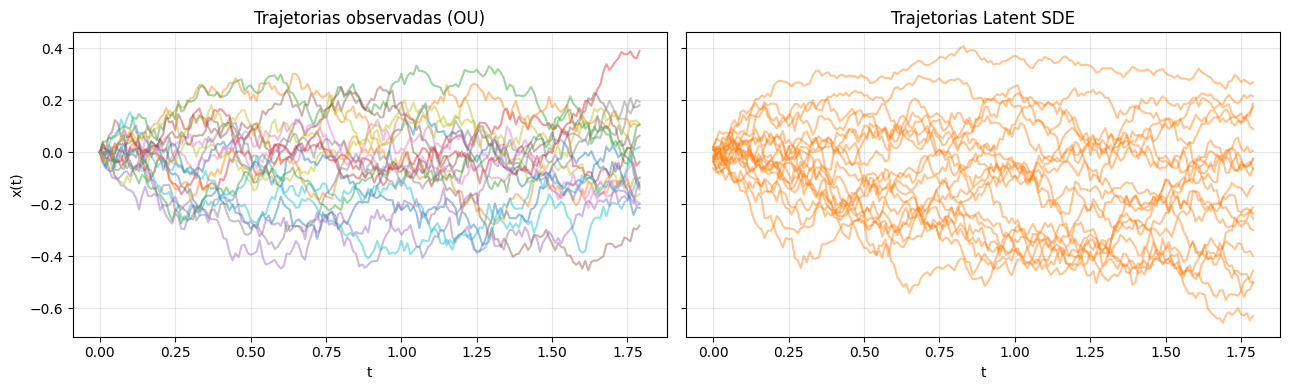

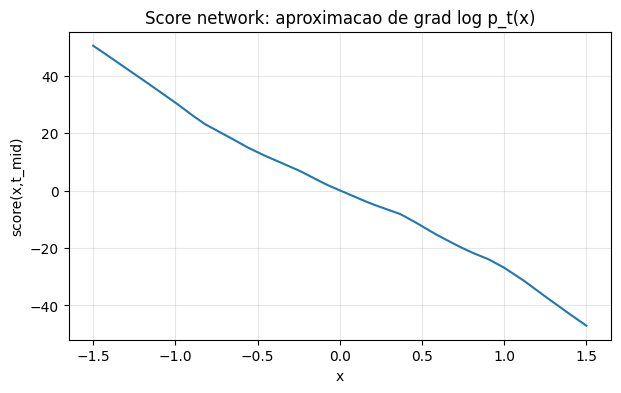

In [39]:
# Visual comparativo: real vs simulado
fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for i in range(20):
    ax[0].plot(t_grid, X[i, :, 0], alpha=0.45)
ax[0].set_title("Trajetorias observadas (OU)")
ax[0].set_xlabel("t")
ax[0].set_ylabel("x(t)")
ax[0].grid(True, alpha=0.3)

for i in range(min(20, X_sim.shape[0])):
    ax[1].plot(t_grid, X_sim[i, :, 0], alpha=0.45, color="tab:orange")
ax[1].set_title("Trajetorias Latent SDE")
ax[1].set_xlabel("t")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Campo de score no tempo medio
x_line = jnp.linspace(-1.5, 1.5, 300).reshape(-1, 1)
t_mid = jnp.full_like(x_line, t_grid[len(t_grid) // 2])
score_line = model.score_fn(x_line, t_mid)

plt.figure(figsize=(7, 4))
plt.plot(x_line[:, 0], score_line[:, 0])
plt.title("Score network: aproximacao de grad log p_t(x)")
plt.xlabel("x")
plt.ylabel("score(x,t_mid)")
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# Diagnostico rapido de colapso
x_train_flat = X[:, :-1, :].reshape(-1, 1)
t_train_flat = jnp.broadcast_to(t_grid[:-1][None, :, None], (X.shape[0], t_grid.shape[0]-1, 1)).reshape(-1, 1)

z_train = model.encode(x_train_flat)
drift_train = model.drift_fn(z_train, t_train_flat)
diff_train = model.diffusion_fn(z_train, t_train_flat)

print("drift mean/std:", float(jnp.mean(drift_train)), float(jnp.std(drift_train)))
print("diff mean/std/min/max:", float(jnp.mean(diff_train)), float(jnp.std(diff_train)), float(jnp.min(diff_train)), float(jnp.max(diff_train)))

sim_std_t = jnp.std(X_sim[:, :, 0], axis=0)
print("sim std @ t0, tmid, tend:", float(sim_std_t[0]), float(sim_std_t[len(sim_std_t)//2]), float(sim_std_t[-1]))
print("real std @ t0, tmid, tend:", float(jnp.std(X[:, :, 0], axis=0)[0]), float(jnp.std(X[:, :, 0], axis=0)[len(sim_std_t)//2]), float(jnp.std(X[:, :, 0], axis=0)[-1]))

drift mean/std: 0.001755723380483687 0.0027929770294576883
diff mean/std/min/max: 0.24452196061611176 0.00024954124819487333 0.24313263595104218 0.24575209617614746
sim std @ t0, tmid, tend: 0.021183397620916367 0.22453728318214417 0.22532597184181213
real std @ t0, tmid, tend: 0.0 0.1726553589105606 0.19525988399982452


In [41]:
# Escala empirica do processo para calibrar pesos
emp_sigma = float(jnp.std((X[:, 1:, :] - X[:, :-1, :]).reshape(-1, 1)) / jnp.sqrt(dt))
print("Empirical sigma (x-space):", emp_sigma)

Empirical sigma (x-space): 0.25057992339134216
